In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
from matplotlib.ticker import FuncFormatter

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

from sklearn.linear_model import LinearRegression

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

In [2]:
# Import Cleaned and Imputed Zillow Data

df_imputed = pd.read_csv("zillow_dataset_imputed.csv")

In [3]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76557 entries, 0 to 76556
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   76557 non-null  float64
 1   bedroomcnt                    76557 non-null  float64
 2   buildingqualitytypeid         76557 non-null  int64  
 3   calculatedbathnbr             76557 non-null  float64
 4   calculatedfinishedsquarefeet  76557 non-null  int64  
 5   finishedsquarefeet12          76557 non-null  int64  
 6   fireplacecnt                  76557 non-null  int64  
 7   fullbathcnt                   76557 non-null  float64
 8   garagecarcnt                  76557 non-null  int64  
 9   garagetotalsqft               76557 non-null  int64  
 10  hashottuborspa                76557 non-null  int64  
 11  heatingorsystemtypeid         76557 non-null  int64  
 12  lotsizesquarefeet             76557 non-null  int64  
 13  p

**PART 4.A - Investigate Feature Relationships:**

In [4]:
# Select Numeric Columns

numeric_cols = df_imputed.select_dtypes(include = "number").columns

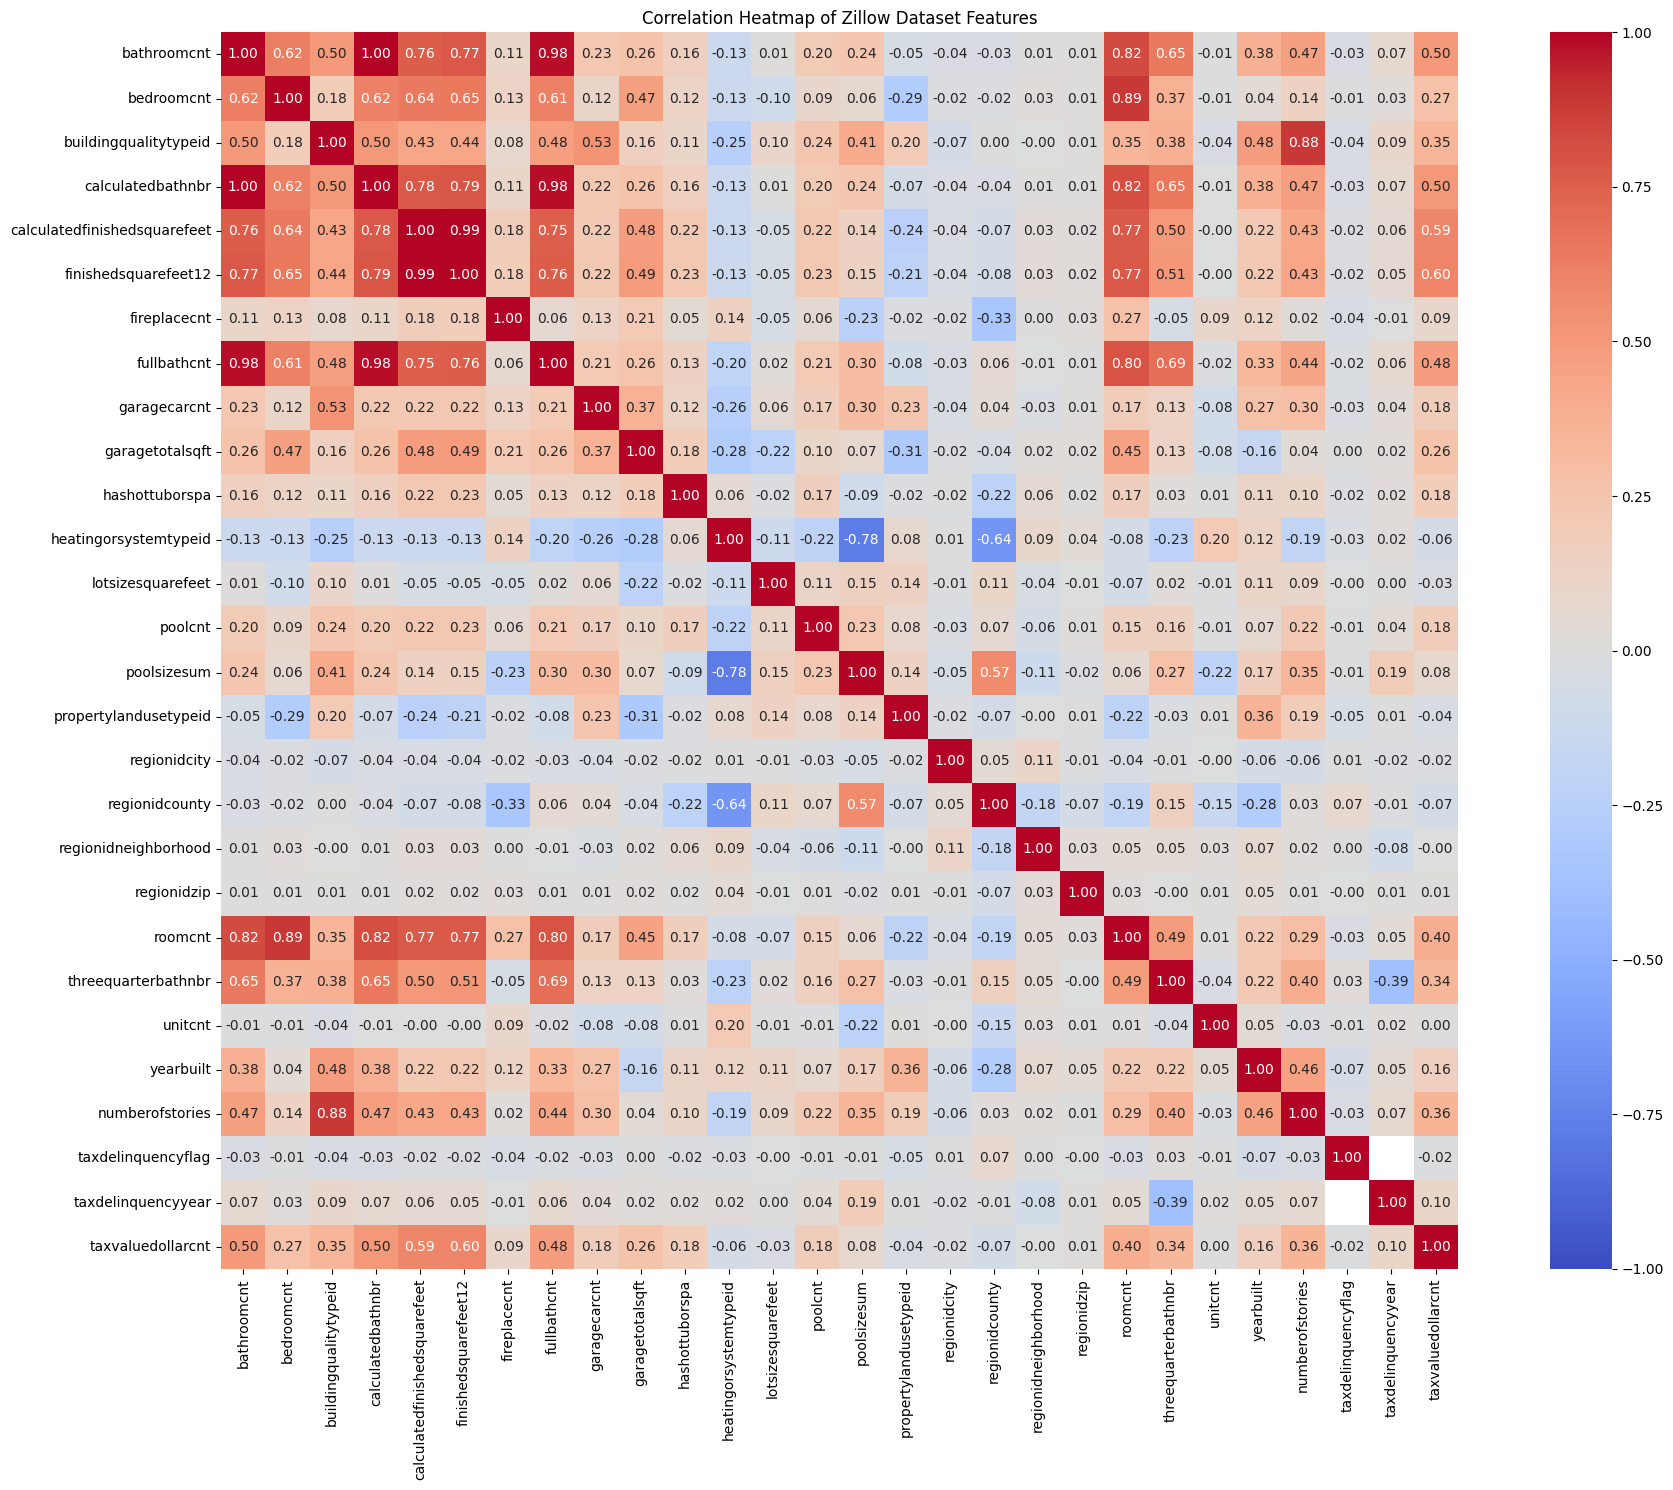

In [5]:
# Heat Map of Correlation Matrix

corr = df_imputed[numeric_cols].corr()

plt.figure(figsize = (20, 15))

sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1, square = True)

plt.title("Correlation Heatmap of Zillow Dataset Features")
plt.tight_layout()

None

**Part 4.A Discussion - Heat Map:**

The Heat Map shows almost perfect correlations between `bathroomcnt`, `calculatedbathnbr`, and `fullbathcnt`. This is not unexpected given that one feature measures the number of rooms that are bathrooms, the second measures the total number of bathrooms, presumably counting 1 for a full bath and 0.5 for a half bath, and the third lists the number of full bethrooms. All three features move together in the same direction, and are going to be highly redundant. We should be able to safely select one and drop the remaining two for our analysis. Also, `threequarterbathnbr` is highly correlated to the other bathroom count variables, and is similarly going to be redundant.

The variable `roomcnt` shows high correlation with `bathroomcnt`, `bedroomcnt`, and `finishedsquarefeet`. This again makes sense, as increasing the number of bedrooms and bathrooms will also increase the number of total rooms in the property, and the number of total rooms should also grow or shrink with the size of the finished space. `roomcnt` may be redundant.

Features that measure the size of the property also show high correlation to each other. finishedsquarefeet12, which is the finished living area square footage, and calculatedfinishedsquarefeet, defined as total finished living area square footage, sound like the same variable and have a correlation to each oterh of 0.99. Again, we should be able to pick just one of these features to use in our analysis.

In [6]:
# Compute F-statistic for all features

X = df_imputed[numeric_cols].drop(["taxvaluedollarcnt", "taxdelinquencyyear"], axis = 1)
y = df_imputed["taxvaluedollarcnt"]

f_vals, p_vals = f_regression(X, y)

f_results = pd.Series(f_vals, index = X.columns).sort_values(ascending = False)
f_results

,0
finishedsquarefeet12,42670.840211
calculatedfinishedsquarefeet,41588.124381
calculatedbathnbr,25701.285790
bathroomcnt,24974.342680
fullbathcnt,23081.733867
roomcnt,14260.422394
numberofstories,11316.503866
buildingqualitytypeid,10372.146663
threequarterbathnbr,10075.676241
bedroomcnt,6011.596438


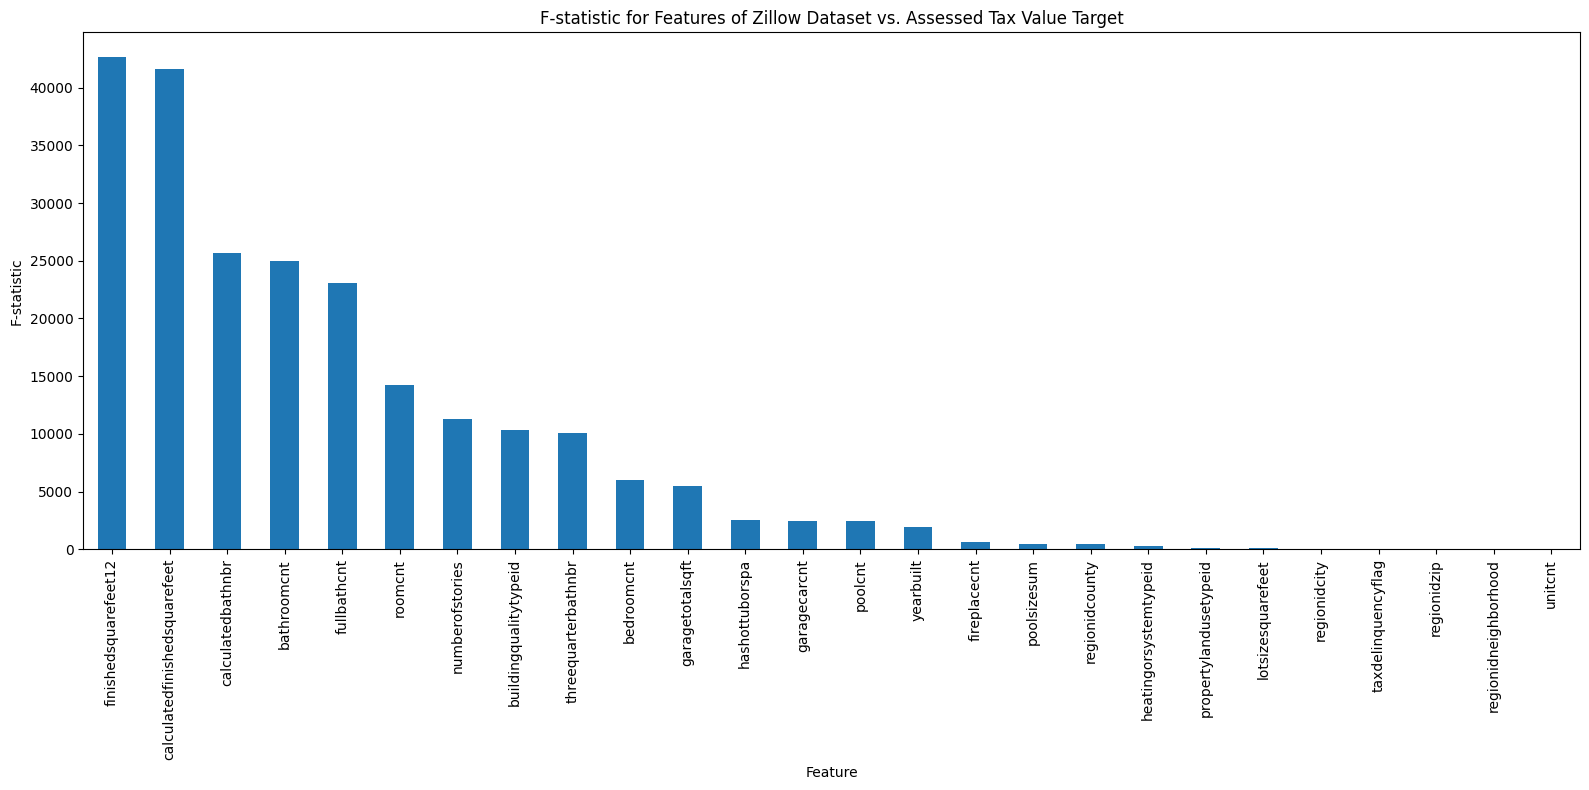

In [7]:
# Make a Bar Chart of the F-statistic for each feature

plt.figure(figsize = (16, 8))

f_results.plot(kind = "bar")

plt.ylabel("F-statistic")
plt.xlabel("Feature")
plt.title("F-statistic for Features of Zillow Dataset vs. Assessed Tax Value Target")
plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()

**Part 4.A Discussion - F-Statistic:**

The F-statistic indicates how strongly each individual feature is related to the target variable, bu looking at variation within each feature across different target outcomes. A large F-statistic means that the feature likely contains information that is useful for predicitng the target variable.

Features that were highly correlated in the Heat Map Correlation Matrix, have similar F-statistics. These include:

1.   `finishedsquarefeet12` and `calculatedfinishedsquarefeet`
2.   `calculatedbathnbr`, `bathroomcnt`, and `fullbathcnt`
3.    `numberofstories` and `buildingqualitytypeid`

Again, it seems like some of these variable pairs will be redundant and could be dropped for future analysis.

Additionally, it seems like the features that ar emost useful in predicting the target variable are related to the general size of the property, while location and other amenities may be less important. `finishedsquarefeet`, `calculatedbathnbr`, `roomcnt`, `numberofstories`, `bedroomcnt`, and even `garagetotalsqft` all seem to have the biggest impact on the assessed tax value.

There is a bit of a drop in the F-statistic values for amenity features like pools and fireplaces, as well as regionaly location variables like county and city. Interestingly, total lot size does not carry a high F-statistic, and it seems that the size of the house is more imprtant than the size of the land.

In [8]:
# Forward Feature Selection

def forward_feature_selection(X, y, model,
                              scoring = 'neg_root_mean_squared_error',
                              cv = 5,
                              tol = None,             # None = no delta cutoff
                                                      # use 0.0 for "no further improvements"
                                                      # and 1e-4 for "point of diminishing returns"
                              max_features = None,    # None = use all features
                              n_jobs = -1,
                              verbose = False
                             ):
    selected_features = []                            # List to store the order of features selected
    remaining_features = list(X.columns)              # Features not yet selected
    best_scores = []                                  # List to store the CV score after each feature addition
    previous_score = float('inf')                     # Initialize previous score for improvement comparison

    # Track the best subset of features and its corresponding score

    best_feature_set = None                           # Best combination of features found so far
    best_score = float('inf')                         # Best CV score observed so far

    while remaining_features:
        scores = {}                                   # Dictionary to hold CV scores for each candidate feature
        for feature in remaining_features:
            current_features = selected_features + [feature]

            # Compute the CV score for the current set of features (negated RMSE, so lower is better)
            cv_score = -cross_val_score(model, X[current_features], y,
                                        scoring = scoring, cv = cv, n_jobs = n_jobs
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key = scores.get)
        current_score = scores[best_feature]

        # Check if the improvement is significant based on the tolerance (tol)
        if tol is not None and previous_score - current_score < tol:
            if verbose:
                print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list and update score trackers
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"\nFeatures: {selected_features[-3:]}, CV Score (RMSE): {current_score:.4f}")

        # Update the best subset if the current score is better than the best so far
        if current_score < best_score:
            best_score = current_score
            best_feature_set = selected_features.copy()

        # Check if the maximum number of features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

    return (
        selected_features,      # List of features in the order they were selected (this will be ALL features if max_features == None
        best_scores,            # List of cross-validation scores corresponding to each addition in the previous list
        best_feature_set,       # The subset of features that achieved the best CV score.
        best_score              # The best CV score
    )

In [9]:
# Define Features and Target

X = df_imputed[numeric_cols].drop(["taxvaluedollarcnt", "taxdelinquencyyear"], axis = 1)
y = df_imputed["taxvaluedollarcnt"]


Features: ['finishedsquarefeet12'], CV Score (RMSE): 335867.2762

Features: ['finishedsquarefeet12', 'bedroomcnt'], CV Score (RMSE): 329459.5035

Features: ['finishedsquarefeet12', 'bedroomcnt', 'bathroomcnt'], CV Score (RMSE): 327092.8842

Features: ['bedroomcnt', 'bathroomcnt', 'numberofstories'], CV Score (RMSE): 326305.5764

Features: ['bathroomcnt', 'numberofstories', 'poolsizesum'], CV Score (RMSE): 325458.7034

Features: ['numberofstories', 'poolsizesum', 'yearbuilt'], CV Score (RMSE): 324619.9777

Features: ['poolsizesum', 'yearbuilt', 'propertylandusetypeid'], CV Score (RMSE): 324010.8241

Features: ['yearbuilt', 'propertylandusetypeid', 'roomcnt'], CV Score (RMSE): 323571.8500

Features: ['propertylandusetypeid', 'roomcnt', 'regionidcounty'], CV Score (RMSE): 323085.5220

Features: ['roomcnt', 'regionidcounty', 'heatingorsystemtypeid'], CV Score (RMSE): 322573.8765

Features: ['regionidcounty', 'heatingorsystemtypeid', 'regionidneighborhood'], CV Score (RMSE): 322338.7090

F

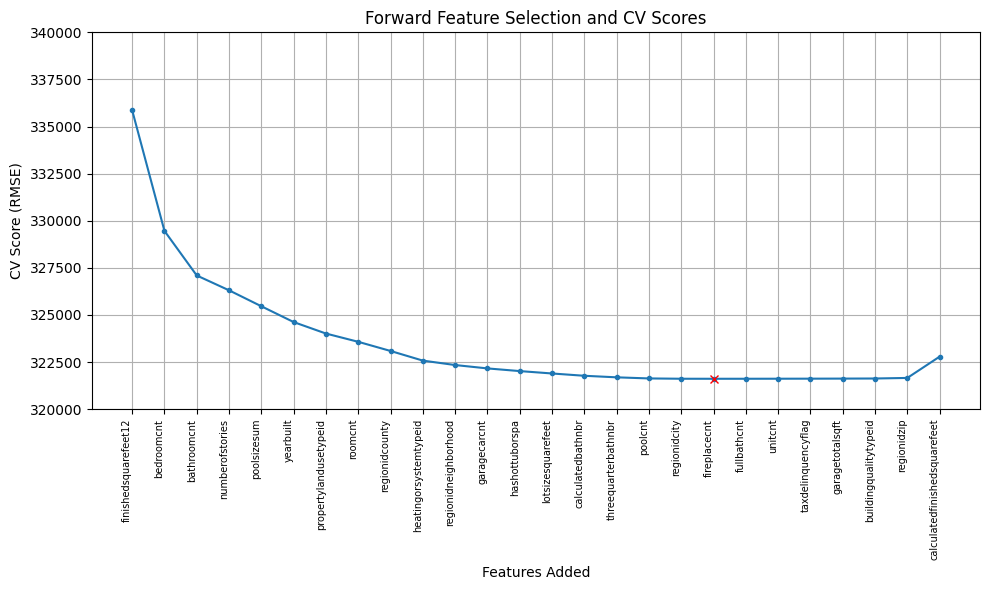

Best Features: ['finishedsquarefeet12', 'bedroomcnt', 'bathroomcnt', 'numberofstories', 'poolsizesum', 'yearbuilt', 'propertylandusetypeid', 'roomcnt', 'regionidcounty', 'heatingorsystemtypeid', 'regionidneighborhood', 'garagecarcnt', 'hashottuborspa', 'lotsizesquarefeet', 'calculatedbathnbr', 'threequarterbathnbr', 'poolcnt', 'regionidcity', 'fireplacecnt']
Best CV Score: 321609.8021


In [12]:
# Run Forward Feature Selection

model = LinearRegression()

selected_features, best_scores, best_forward_features, best_forward_score = (forward_feature_selection(X, y, model, verbose = True))

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize = (10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
plt.plot([index + 1], best_forward_score, marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize = 7)
plt.title('Forward Feature Selection and CV Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()

# Change scale of y-axis to better see better see the behavior around the minimum point
plt.ylim(320000, 340000)

plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_forward_score:.4f}")

In [13]:
# Backward Feature Selection

def backward_feature_selection(X, y, model,
                               scoring = 'neg_root_mean_squared_error',
                               cv = 5,
                               tol = None,             # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"
                               max_features = None,    # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs = -1,
                               verbose = True
                              ):

    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y,
                                scoring = scoring, cv = cv,
                                n_jobs = n_jobs).mean()

    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)

    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)

    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)

    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (RMSE): {np.around(initial_score, 4)}\n')

    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features

    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')

        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None

        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(new_score, 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set

        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break

        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()

        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)

        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (RMSE) {np.around(lowest_score, 4)}\n')
        round_num += 1

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score              # Best (lowest) CV score
    )

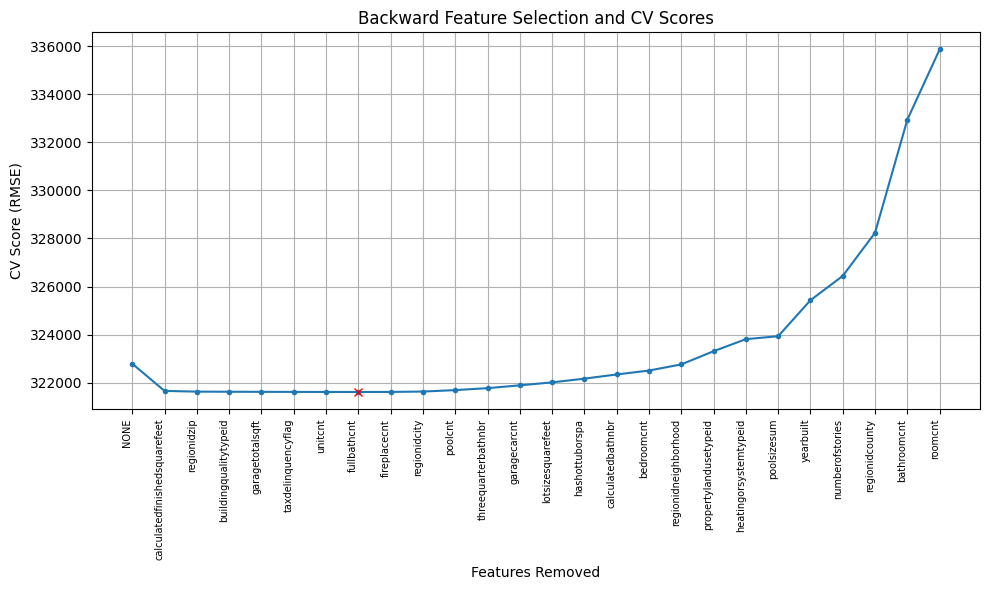

Best feature set: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'finishedsquarefeet12', 'fireplacecnt', 'garagecarcnt', 'hashottuborspa', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'roomcnt', 'threequarterbathnbr', 'yearbuilt', 'numberofstories']
CV score (RMSE): 321609.8021


In [14]:
# Run Backward Feature Selection

model = LinearRegression()

selected_features, best_scores, best_feature_set, best_backward_score = (backward_feature_selection(X, y, model, verbose = False))

# Plot the results

plt.figure(figsize = (10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize=7)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and cv score

print("Best feature set:", best_feature_set)
print("CV score (RMSE):", np.around(best_backward_score, 4))

**Part 4.A Discussion - Forward and Backward Feature Selection:**

Both forward and backward feature selection with linear regression yield the same Root Mean Squared Error (RMSE) of 321,609.80. The RMSE feels high, but that is likely partly due to the model being used linear regression is ptrobably not the best model for this problem and dataset, and the fact that there are still a significant number of properties valued well over $1 million on the cleaned and filtered data.

Forward and backward feature selection also identified the same sevenfeatures to remove as follows:
`calculatedfinishedsquarefeet`
`regionidzip`
`buildingqualitytypeid`
`garagetotalsqft`
`taxdelinquencyflag`
`unitcnt`
`fullbathcnt`

****PART 4.B - 2-Dimensional Visualizations for Interesting Patterns:****

In [ ]:
# Scatter Plots